In [6]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Matplotlib is building the font cache; this may take a moment.


In [7]:
data=yf.download('AAPL', start='2022-01-01', end='2023-01-01')
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.786362,178.636183,173.586157,173.703368,104487900
2022-01-04,175.530029,178.694850,174.963487,178.392046,99310400
2022-01-05,170.860931,175.989104,170.587430,175.442101,94537600
2022-01-06,168.008682,171.232108,167.657036,168.692436,96904000
2022-01-07,168.174744,170.099030,167.061198,168.878037,86709100


In [8]:
data['SMA20']=data['Close'].rolling(window=20).mean()
data['SMA50']=data['Close'].rolling(window=50).mean()

In [9]:
data['Signal'] = 0

In [11]:
signal_values=np.where(data['SMA20'][20:]>data['SMA50'][20:], 1, 0)
data.iloc[20:, data.columns.get_loc('Signal')]=signal_values
data['Position']=data['Signal'].diff()

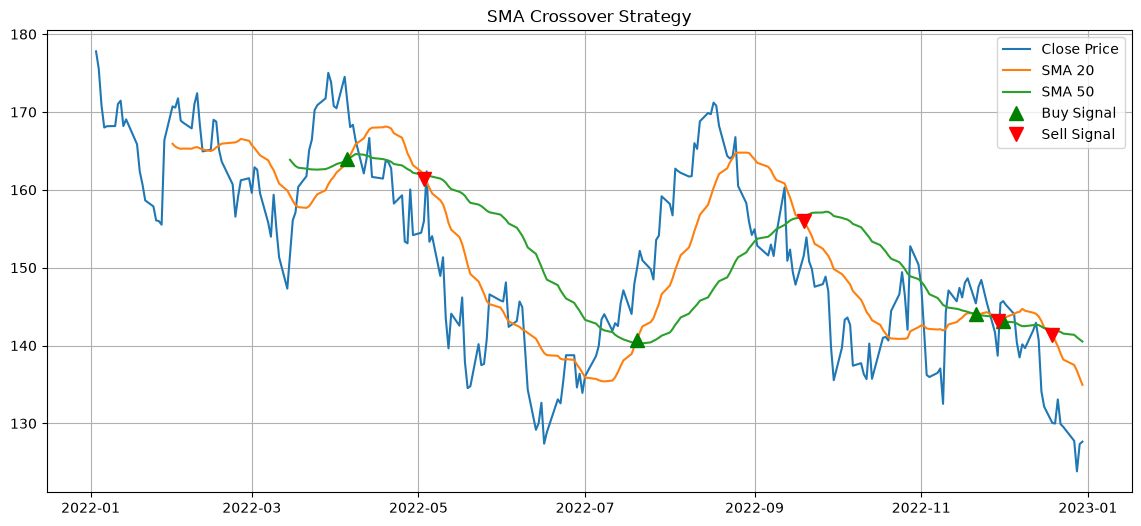

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(data['Close'], label='Close Price')
plt.plot(data['SMA20'], label='SMA 20')
plt.plot(data['SMA50'], label='SMA 50')
plt.plot(data[data['Position']==1].index, 
         data['SMA20'][data['Position']==1],
         '^', markersize=10, color='g', label='Buy Signal')
plt.plot(data[data['Position']==-1].index, 
         data['SMA20'][data['Position']==-1],
         'v', markersize=10, color='r', label='Sell Signal')
plt.title('SMA Crossover Strategy')
plt.legend()
plt.grid()
plt.show()